In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ============================================
# CHANGE THIS TO ANY COMPANY YOU WANT TO VALUE
# ============================================
TICKER = "FSLR"
COMPANY_NAME = "First Solar"
PROJECTION_YEARS = 5

# ============================================
# AUTO-CALCULATE ASSUMPTIONS
# ============================================
stock = yf.Ticker(TICKER)
info = stock.info

revenue_growth = info.get('revenueGrowth', None)
earnings_growth = info.get('earningsGrowth', None)
beta = info.get('beta', 1.0)
sector = info.get('sector', 'Unknown')
industry = info.get('industry', 'Unknown')
profit_margin = info.get('profitMargins', None)
roe = info.get('returnOnEquity', None)
analyst_target = info.get('targetMeanPrice', None)
recommendation = info.get('recommendationKey', 'N/A')

# Auto discount rate from beta
if beta < 0.8:
    DISCOUNT_RATE = 0.08
    risk_label = "Low risk"
elif beta < 1.2:
    DISCOUNT_RATE = 0.10
    risk_label = "Medium risk"
elif beta < 1.6:
    DISCOUNT_RATE = 0.12
    risk_label = "High risk"
else:
    DISCOUNT_RATE = 0.15
    risk_label = "Very high risk"

# Auto growth rate from analyst estimates
GROWTH_RATE = round(revenue_growth, 3) if revenue_growth else 0.05

# Auto terminal growth rate
if revenue_growth and revenue_growth > 0.15:
    TERMINAL_GROWTH_RATE = 0.04
elif revenue_growth and revenue_growth > 0.05:
    TERMINAL_GROWTH_RATE = 0.03
else:
    TERMINAL_GROWTH_RATE = 0.02

print(f"{'='*55}")
print(f"  {COMPANY_NAME} ({TICKER}) — AUTO ASSUMPTIONS")
print(f"{'='*55}")
print(f"  Sector:              {sector}")
print(f"  Industry:            {industry}")
print(f"  Analyst view:        {recommendation.upper()}")
if analyst_target:
    print(f"  Analyst target:      ${analyst_target:.2f}")
print(f"\n  Beta:                {beta:.2f} → {risk_label}")
print(f"  Revenue growth:      {GROWTH_RATE*100:.1f}%")
print(f"\n  ✅ DISCOUNT_RATE        = {DISCOUNT_RATE}")
print(f"  ✅ GROWTH_RATE          = {GROWTH_RATE}")
print(f"  ✅ TERMINAL_GROWTH_RATE = {TERMINAL_GROWTH_RATE}")
print(f"{'='*55}")

  First Solar (FSLR) — AUTO ASSUMPTIONS
  Sector:              Technology
  Industry:            Solar
  Analyst view:        BUY
  Analyst target:      $255.87

  Beta:                1.65 → Very high risk
  Revenue growth:      11.1%

  ✅ DISCOUNT_RATE        = 0.15
  ✅ GROWTH_RATE          = 0.111
  ✅ TERMINAL_GROWTH_RATE = 0.03


In [3]:
# ============================================
# ASSUMPTION HELPER — run this before the DCF
# ============================================
stock = yf.Ticker(TICKER)
info = stock.info

# Pull relevant data
revenue_growth = info.get('revenueGrowth', None)
earnings_growth = info.get('earningsGrowth', None)
earnings_growth_5y = info.get('earningsQuarterlyGrowth', None)
beta = info.get('beta', 1.0)
sector = info.get('sector', 'Unknown')
industry = info.get('industry', 'Unknown')
profit_margin = info.get('profitMargins', None)
roe = info.get('returnOnEquity', None)
debt_to_equity = info.get('debtToEquity', None)
analyst_target = info.get('targetMeanPrice', None)
recommendation = info.get('recommendationKey', 'N/A')

# Suggested discount rate based on beta
# Higher beta = riskier stock = higher required return
if beta < 0.8:
    suggested_discount = 0.08
    risk_label = "Low risk"
elif beta < 1.2:
    suggested_discount = 0.10
    risk_label = "Medium risk"
elif beta < 1.6:
    suggested_discount = 0.12
    risk_label = "High risk"
else:
    suggested_discount = 0.15
    risk_label = "Very high risk"

# Suggested growth rate based on analyst estimates
if revenue_growth:
    suggested_growth = round(revenue_growth, 3)
else:
    suggested_growth = 0.05  # default 5% if no data

# Suggested terminal growth rate
# Rule of thumb: mature companies ~2-3%, high growth ~3-4%
if revenue_growth and revenue_growth > 0.15:
    suggested_terminal = 0.04
elif revenue_growth and revenue_growth > 0.05:
    suggested_terminal = 0.03
else:
    suggested_terminal = 0.02

print(f"{'='*55}")
print(f"  ASSUMPTION GUIDE — {COMPANY_NAME} ({TICKER})")
print(f"{'='*55}")
print(f"\n  Sector:          {sector}")
print(f"  Industry:        {industry}")
print(f"  Analyst view:    {recommendation.upper()}")
print(f"  Analyst target:  ${analyst_target:.2f}" if analyst_target else "  Analyst target:  N/A")

print(f"\n  --- GROWTH ---")
print(f"  Revenue growth (TTM):   {revenue_growth*100:.1f}%" if revenue_growth else "  Revenue growth:   N/A")
print(f"  Earnings growth (TTM):  {earnings_growth*100:.1f}%" if earnings_growth else "  Earnings growth:  N/A")
print(f"  ✅ Suggested GROWTH_RATE = {suggested_growth}")

print(f"\n  --- DISCOUNT RATE ---")
print(f"  Beta:            {beta:.2f} ({risk_label})")
print(f"  ✅ Suggested DISCOUNT_RATE = {suggested_discount}")

print(f"\n  --- TERMINAL GROWTH ---")
print(f"  Profit margin:   {profit_margin*100:.1f}%" if profit_margin else "  Profit margin:   N/A")
print(f"  Return on equity:{roe*100:.1f}%" if roe else "  Return on equity: N/A")
print(f"  ✅ Suggested TERMINAL_GROWTH_RATE = {suggested_terminal}")

print(f"\n  --- COPY THESE INTO CELL 2 ---")
print(f"  DISCOUNT_RATE        = {suggested_discount}")
print(f"  TERMINAL_GROWTH_RATE = {suggested_terminal}")
print(f"  GROWTH_RATE          = {suggested_growth}")
print(f"{'='*55}")

  ASSUMPTION GUIDE — First Solar (FSLR)

  Sector:          Technology
  Industry:        Solar
  Analyst view:    BUY
  Analyst target:  $255.87

  --- GROWTH ---
  Revenue growth (TTM):   11.1%
  Earnings growth (TTM):  32.3%
  ✅ Suggested GROWTH_RATE = 0.111

  --- DISCOUNT RATE ---
  Beta:            1.65 (Very high risk)
  ✅ Suggested DISCOUNT_RATE = 0.15

  --- TERMINAL GROWTH ---
  Profit margin:   29.3%
  Return on equity:17.4%
  ✅ Suggested TERMINAL_GROWTH_RATE = 0.03

  --- COPY THESE INTO CELL 2 ---
  DISCOUNT_RATE        = 0.15
  TERMINAL_GROWTH_RATE = 0.03
  GROWTH_RATE          = 0.111


In [4]:
stock = yf.Ticker(TICKER)
info = stock.info

# Key metrics
current_price = info.get('currentPrice') or info.get('regularMarketPrice')
shares_outstanding = info.get('sharesOutstanding')
market_cap = info.get('marketCap')
free_cashflow = info.get('freeCashflow')
revenue = info.get('totalRevenue')
ebitda = info.get('ebitda')
net_income = info.get('netIncomeToCommon')
total_debt = info.get('totalDebt', 0)
cash = info.get('totalCash', 0)
pe_ratio = info.get('trailingPE')
forward_pe = info.get('forwardPE')
ev_ebitda = info.get('enterpriseToEbitda')
revenue_growth = info.get('revenueGrowth', 0.05)

print(f"\n{'='*50}")
print(f"  {COMPANY_NAME} — Live Data")
print(f"{'='*50}")
print(f"  Current price:     £/$ {current_price:,.2f}")
print(f"  Market cap:        £/$ {market_cap/1e9:,.1f}bn")
print(f"  Free cash flow:    £/$ {free_cashflow/1e9:,.1f}bn")
print(f"  Revenue:           £/$ {revenue/1e9:,.1f}bn")
print(f"  EBITDA:            £/$ {ebitda/1e9:,.1f}bn")
print(f"  P/E ratio:         {pe_ratio:.1f}x")
print(f"  EV/EBITDA:         {ev_ebitda:.1f}x")
print(f"  GROWTH_RATE:    {GROWTH_RATE*100:.1f}%")
print(f"{'='*50}")


  First Solar — Live Data
  Current price:     £/$ 190.29
  Market cap:        £/$ 20.4bn
  Free cash flow:    £/$ 1.0bn
  Revenue:           £/$ 5.2bn
  EBITDA:            £/$ 2.1bn
  P/E ratio:         13.4x
  EV/EBITDA:         8.6x
  GROWTH_RATE:    11.1%


In [5]:
# ============================================
# VIABILITY CHECK — run before DCF
# ============================================
issues = []
warnings_list = []

# Hard blockers
if not free_cashflow or free_cashflow == 0:
    issues.append("❌ No free cash flow data — DCF not viable")
if free_cashflow and free_cashflow < 0:
    issues.append("❌ Negative free cash flow — DCF not viable")
if not shares_outstanding or shares_outstanding == 0:
    issues.append("❌ No shares outstanding data")
if not ebitda or ebitda == 0:
    issues.append("❌ No EBITDA data — comps not viable")
if DISCOUNT_RATE - TERMINAL_GROWTH_RATE <= 0:
    issues.append("❌ Terminal growth rate exceeds discount rate — model breaks")

# Soft warnings
if not revenue_growth:
    warnings_list.append("⚠️  No analyst growth estimate — using default 5%")
if net_income and net_income < 0:
    warnings_list.append("⚠️  Loss-making company — P/E comps not meaningful")
if debt_to_equity and debt_to_equity > 200:
    warnings_list.append("⚠️  Very high debt — equity value may be distorted")
if sector in ['Financial Services', 'Banking', 'Insurance']:
    warnings_list.append("⚠️  Financial sector — DCF unreliable, use P/B or DDM instead")

# Set flags based on issues
RUN_DCF = not any("free cash flow" in i or "Terminal" in i or "shares" in i for i in issues)
RUN_COMPS = not any("EBITDA" in i or "shares" in i for i in issues)

print(f"{'='*55}")
print(f"  VIABILITY CHECK — {COMPANY_NAME} ({TICKER})")
print(f"{'='*55}")

if not issues and not warnings_list:
    print("\n  ✅ All checks passed — safe to run full model\n")
else:
    if issues:
        print("\n  BLOCKERS:")
        for issue in issues:
            print(f"    {issue}")
    if warnings_list:
        print("\n  WARNINGS:")
        for w in warnings_list:
            print(f"    {w}")

print(f"\n  RUN_DCF   = {RUN_DCF}")
print(f"  RUN_COMPS = {RUN_COMPS}")
print(f"{'='*55}")

  VIABILITY CHECK — First Solar (FSLR)

  ✅ All checks passed — safe to run full model


  RUN_DCF   = True
  RUN_COMPS = True


In [6]:
if not RUN_DCF:
    print("⛔ DCF skipped — see viability check above")
else:
    # rest of DCF code...
    # Project free cash flows forward
    fcf_projections = []
    fcf = free_cashflow

    growth_rates = []
    for year in range(1, PROJECTION_YEARS + 1):
        if year <= 3:
            growth = GROWTH_RATE
        else:
            growth = GROWTH_RATE * 0.6
        growth_rates.append(growth)

    for i, growth in enumerate(growth_rates):
        fcf = fcf * (1 + growth)
        fcf_projections.append(fcf)

    pv_fcfs = []
    for i, fcf in enumerate(fcf_projections):
        pv = fcf / (1 + DISCOUNT_RATE) ** (i + 1)
        pv_fcfs.append(pv)

    terminal_value = fcf_projections[-1] * (1 + TERMINAL_GROWTH_RATE) / \
                     (DISCOUNT_RATE - TERMINAL_GROWTH_RATE)
    pv_terminal = terminal_value / (1 + DISCOUNT_RATE) ** PROJECTION_YEARS

    enterprise_value = sum(pv_fcfs) + pv_terminal
    equity_value = enterprise_value - total_debt + cash
    dcf_price_per_share = equity_value / shares_outstanding

    upside = ((dcf_price_per_share - current_price) / current_price) * 100

    print(f"\n{'='*50}")
    print(f"  DCF VALUATION — {COMPANY_NAME}")
    print(f"{'='*50}")
    for i, (fcf, pv) in enumerate(zip(fcf_projections, pv_fcfs)):
        print(f"  Year {i+1}: FCF ${fcf/1e9:.1f}bn  →  PV ${pv/1e9:.1f}bn")
    print(f"\n  PV of FCFs:        ${sum(pv_fcfs)/1e9:.1f}bn")
    print(f"  PV terminal value: ${pv_terminal/1e9:.1f}bn")
    print(f"  Enterprise value:  ${enterprise_value/1e9:.1f}bn")
    print(f"  Equity value:      ${equity_value/1e9:.1f}bn")
    print(f"\n  DCF price target:  ${dcf_price_per_share:.2f}")
    print(f"  Current price:     ${current_price:.2f}")
    print(f"  Implied upside:    {upside:+.1f}%")
    print(f"{'='*50}")


  DCF VALUATION — First Solar
  Year 1: FCF $1.1bn  →  PV $0.9bn
  Year 2: FCF $1.2bn  →  PV $0.9bn
  Year 3: FCF $1.3bn  →  PV $0.9bn
  Year 4: FCF $1.4bn  →  PV $0.8bn
  Year 5: FCF $1.5bn  →  PV $0.7bn

  PV of FCFs:        $4.3bn
  PV terminal value: $6.4bn
  Enterprise value:  $10.7bn
  Equity value:      $12.9bn

  DCF price target:  $119.94
  Current price:     $190.29
  Implied upside:    -37.0%


In [7]:
if not RUN_COMPS:
    print("⛔ Comps skipped — see viability check above")
else:
    sector_multiples = {
        'Technology':            {'pe': 28.0, 'ev_ebitda': 20.0},
        'Financial Services':    {'pe': 12.0, 'ev_ebitda': 10.0},
        'Consumer Cyclical':     {'pe': 18.0, 'ev_ebitda': 12.0},
        'Consumer Defensive':    {'pe': 20.0, 'ev_ebitda': 13.0},
        'Healthcare':            {'pe': 22.0, 'ev_ebitda': 14.0},
        'Energy':                {'pe': 10.0, 'ev_ebitda': 7.0},
        'Industrials':           {'pe': 19.0, 'ev_ebitda': 12.0},
        'Communication Services':{'pe': 16.0, 'ev_ebitda': 11.0},
        'Default':               {'pe': 18.0, 'ev_ebitda': 12.0},
    }

    multiples = sector_multiples.get(sector, sector_multiples['Default'])

    # P/E implied price
    eps = net_income / shares_outstanding
    pe_implied_price = eps * multiples['pe']

    # EV/EBITDA implied price
    ev_implied = ebitda * multiples['ev_ebitda']
    equity_from_ev = ev_implied - total_debt + cash
    ev_implied_price = equity_from_ev / shares_outstanding

    # Average — only include DCF if it actually ran
    if RUN_DCF:
        avg_price = np.mean([dcf_price_per_share, pe_implied_price, ev_implied_price])
    else:
        avg_price = np.mean([pe_implied_price, ev_implied_price])
        print("  ℹ️  DCF excluded from average — using comps only\n")

    avg_upside = ((avg_price - current_price) / current_price) * 100

    print(f"\n{'='*50}")
    print(f"  COMPARABLE COMPANY ANALYSIS — {sector}")
    print(f"{'='*50}")
    print(f"  Sector avg P/E:       {multiples['pe']}x")
    print(f"  Sector avg EV/EBITDA: {multiples['ev_ebitda']}x")
    print(f"\n  P/E implied price:    ${pe_implied_price:.2f}")
    print(f"  EV/EBITDA implied:    ${ev_implied_price:.2f}")
    if RUN_DCF:
        print(f"  DCF implied price:    ${dcf_price_per_share:.2f}")
    print(f"\n  Average target:       ${avg_price:.2f}")
    print(f"  Current price:        ${current_price:.2f}")
    print(f"  Blended upside:       {avg_upside:+.1f}%")
    print(f"{'='*50}")


  COMPARABLE COMPANY ANALYSIS — Technology
  Sector avg P/E:       28.0x
  Sector avg EV/EBITDA: 20.0x

  P/E implied price:    $398.75
  EV/EBITDA implied:    $416.75
  DCF implied price:    $119.94

  Average target:       $311.81
  Current price:        $190.29
  Blended upside:       +63.9%


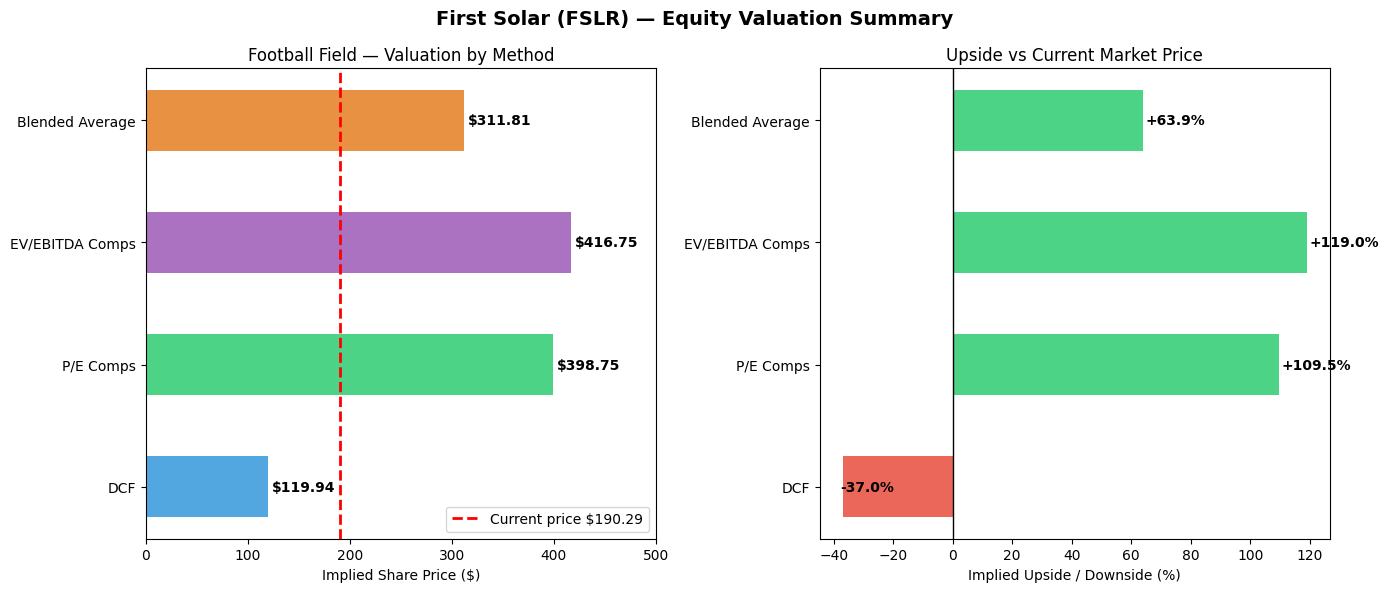

Chart saved ✓


In [8]:
if not RUN_DCF and not RUN_COMPS:
    print("⛔ Chart skipped — no valid valuation methods ran")

else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'{COMPANY_NAME} ({TICKER}) — Equity Valuation Summary',
                 fontsize=14, fontweight='bold')

    # Build methods and prices dynamically based on what ran
    methods = []
    prices = []
    colors = []

    if RUN_DCF:
        methods.append('DCF')
        prices.append(dcf_price_per_share)
        colors.append('#3498db')

    if RUN_COMPS:
        methods.append('P/E Comps')
        prices.append(pe_implied_price)
        colors.append('#2ecc71')

        methods.append('EV/EBITDA Comps')
        prices.append(ev_implied_price)
        colors.append('#9b59b6')

    methods.append('Blended Average')
    prices.append(avg_price)
    colors.append('#e67e22')

    # Chart 1: Football field
    ax1 = axes[0]
    bars = ax1.barh(methods, prices, color=colors, alpha=0.85, height=0.5)
    ax1.axvline(x=current_price, color='red', linewidth=2,
                linestyle='--', label=f'Current price ${current_price:.2f}')

    for bar, price in zip(bars, prices):
        ax1.text(bar.get_width() + (max(prices) * 0.01),
                 bar.get_y() + bar.get_height()/2,
                 f'${price:.2f}', va='center', fontweight='bold', fontsize=10)

    ax1.set_xlabel('Implied Share Price ($)')
    ax1.set_title('Football Field — Valuation by Method')
    ax1.legend()
    ax1.set_xlim(0, max(prices) * 1.2)

    # Chart 2: Upside/downside
    ax2 = axes[1]
    upsides = [(p - current_price) / current_price * 100 for p in prices]
    bar_colors2 = ['#2ecc71' if u > 0 else '#e74c3c' for u in upsides]
    bars2 = ax2.barh(methods, upsides, color=bar_colors2, alpha=0.85, height=0.5)
    ax2.axvline(x=0, color='black', linewidth=1)

    for bar, upside_val in zip(bars2, upsides):
        x_pos = bar.get_width() + (1 if upside_val >= 0 else -1)
        ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
                 f'{upside_val:+.1f}%', va='center', fontweight='bold', fontsize=10)

    ax2.set_xlabel('Implied Upside / Downside (%)')
    ax2.set_title('Upside vs Current Market Price')

    plt.tight_layout()
    plt.savefig(f'{TICKER}_valuation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved ✓")